<a href="https://colab.research.google.com/github/muhammadtegarkurniawan/Tugas/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.segmentation import active_contour
from skimage.filters import gaussian

In [58]:
from google.colab import files
uploaded = files.upload()

import os
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Saving dmfovrwdeskdyvledzph.jpg to dmfovrwdeskdyvledzph (1).jpg


In [59]:
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

In [60]:
# Blur untuk bantu contour
img_smooth = gaussian(gray, sigma=3)

# Inisialisasi lingkaran awal
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 100*np.sin(s)
c = 100 + 100*np.cos(s)

init = np.array([r, c]).T

snake = active_contour(img_smooth, init, alpha=0.015, beta=10, gamma=0.001)

In [61]:
# Konversi ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 🔴 MERAH itu ada 2 range di HSV
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

# Mask 1 & 2 digabung
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

mask = mask1 + mask2

# 🔹 Noise removal (PENTING!)
kernel = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)   # hapus noise kecil
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # tutup lubang

# 🔹 Hasil segmentasi
result_color = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

In [62]:
edges = cv2.Canny(gray, 100, 200)

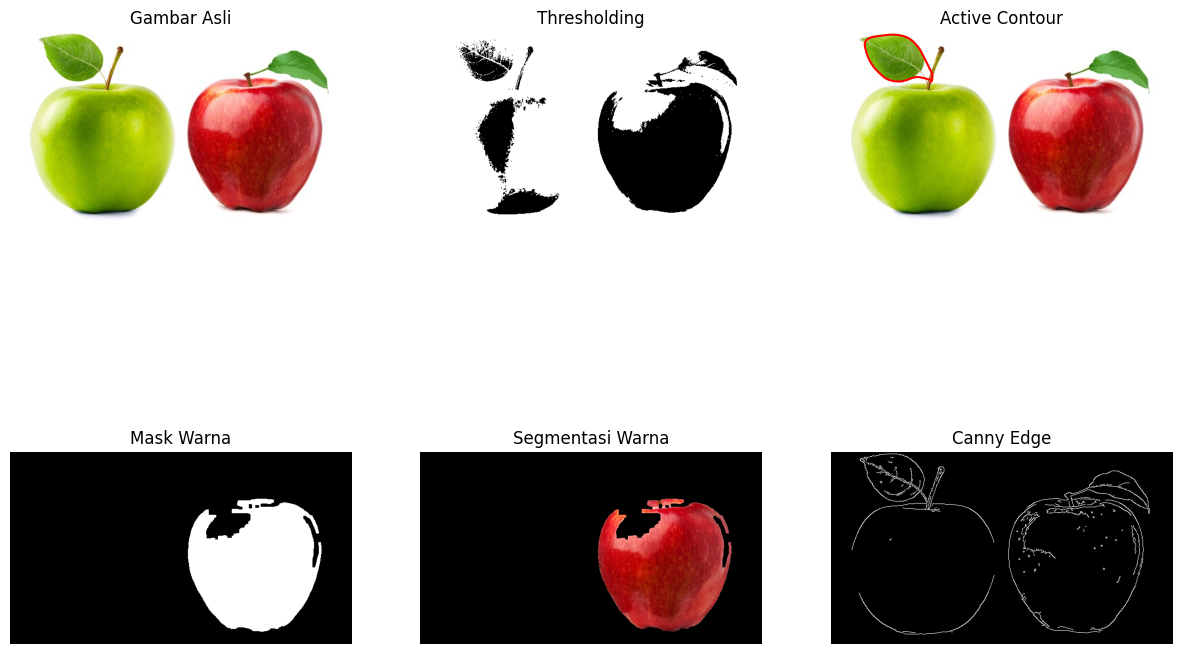

In [63]:
plt.figure(figsize=(15,10))

# Asli
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')

# Threshold
plt.subplot(2,3,2)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholding")
plt.axis('off')

# Active Contour
plt.subplot(2,3,3)
plt.imshow(img_rgb)
plt.plot(snake[:, 1], snake[:, 0], '-r')
plt.title("Active Contour")
plt.axis('off')

# Mask Warna
plt.subplot(2,3,4)
plt.imshow(mask, cmap='gray')
plt.title("Mask Warna")
plt.axis('off')

# Hasil Warna
plt.subplot(2,3,5)
plt.imshow(result_color)
plt.title("Segmentasi Warna")
plt.axis('off')

# Canny
plt.subplot(2,3,6)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge")
plt.axis('off')

plt.show()